# Au sein d'une formation, l'offre de places, le volume de candidatures et le nombre d'admis sont-ils corrélés entre eux ?

## Pouvons nous prédire le nombre d'admis à partir de la capacité d'une formation, la part féminine suit-elle la même logique ?


    Import de notre ficheir CSV et de nos librairies

In [2]:
#Import de nos modules
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Importation de notre fichier CSV
tableauDonnees_df=pd.read_csv("_etude_statistique.csv", sep=";")
print(tableauDonnees_df)


    code_formation  x1_capacite  x2_candidats  x3_candidates  y_total_admis
0               10           90          4332           1055             56
1              100           85          3129            763             59
2            10001           68           413            319             21
3            10002           82           242            177             22
4            10003          120           756            563             75
5            10005          186          2180           1252            133
6            10007          115           857            624             60
7            10008           58           309            116             37
8            10009          160           760            348             79
9            10011           50           458             32             26
10           10012           52           723             50             46
11           10014           56          1109            567             45
12          

### Représentation graphique

#### Boite à moustache comparant la différence entre les hommes et femmes à avoir postulé dans une formation 

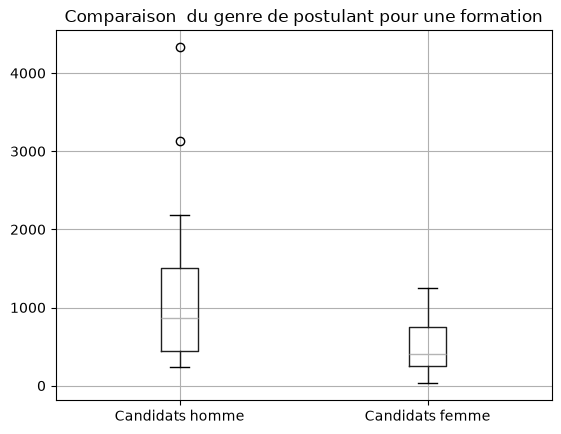

In [3]:
tableauDonnees_df.boxplot(column=["x2_candidats", "x3_candidates"])

plt.title("Comparaison  du genre de postulant pour une formation")
plt.xticks([1, 2], ["Candidats homme", "Candidats femme"])
plt.show()

#### Boite à moustache comparant la différence de capacité des formations fasse aux admissions

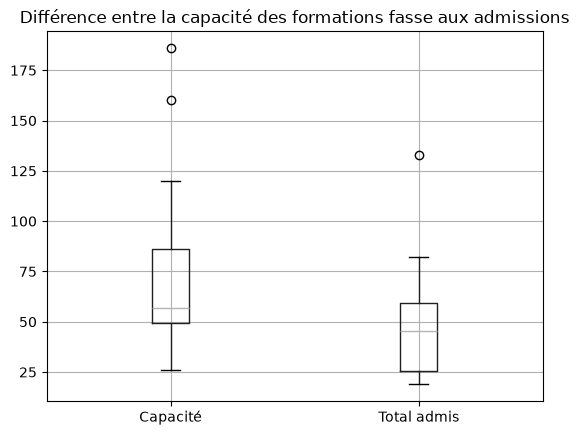

In [4]:
tableauDonnees_df.boxplot(column=["x1_capacite", "y_total_admis"])

plt.title("Différence entre la capacité des formations fasse aux admissions")
plt.xticks([1, 2], ["Capacité", "Total admis"])
plt.show()

#### Nuage de point représentant le nombre d'admis par capacité d'admission de chaque formation

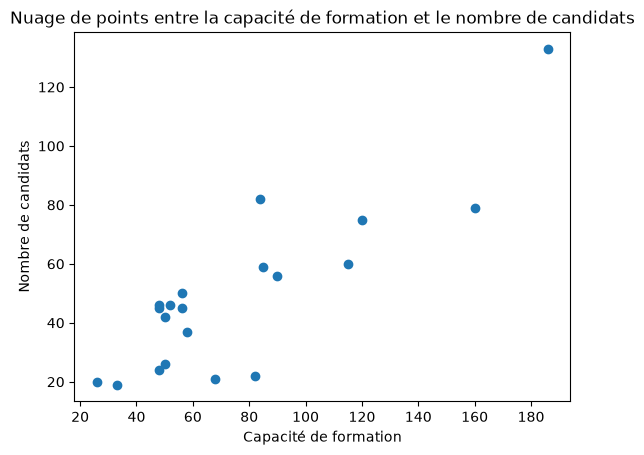

In [6]:
x = tableauDonnees_df["x1_capacite"]
y = tableauDonnees_df["y_total_admis"]



plt.scatter(x, y)
plt.title("Nuage de points entre la capacité de formation et le nombre de candidats")
plt.xlabel("Capacité de formation")
plt.ylabel("Nombre de candidats")
plt.show()

#### Nuage de points entre la capcité d'une formation et le nombre de candidates

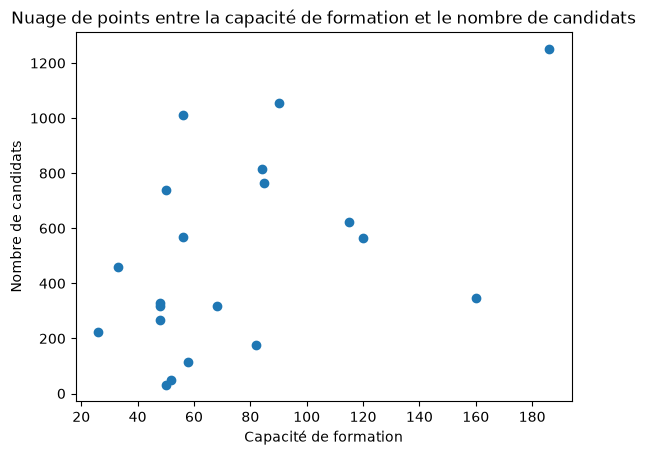

In [7]:
x = tableauDonnees_df["x1_capacite"]
y = tableauDonnees_df["x3_candidates"]



plt.scatter(x, y)
plt.title("Nuage de points entre la capacité de formation et le nombre de candidats")
plt.xlabel("Capacité de formation")
plt.ylabel("Nombre de candidats")
plt.show()

### Regression linéaire multiple

In [18]:
#J'importe les valeurs de mes colonne dans des tableaux semblable à une matrice
x = tableauDonnees_df[["x1_capacite", "x2_candidats", "x3_candidates"]].values
y = tableauDonnees_df["y_total_admis"].values

#Dans la matrice de x, je rajoute 1 devant chaque ligne :
essaie_li = []
for i in range(len(x)) :
    essaie_li.append([1])
    for element in x[i] :
        essaie_li[i].append(element)

#Je passe de le type de chaque valeur de la matrice x en entier
for i in range(len(essaie_li)):
    for j in range(len(essaie_li[i])):
        essaie_li[i][j] = int(essaie_li[i][j])

x = essaie_li

#Je créer la matrice transposé de x
tx_li =[]
colonne = len(x[0])
ligne = len(x)
for j in range(colonne):
    nouvelle_ligne = []
    for i in range(ligne):
        nouvelle_ligne.append(x[i][j])
    tx_li.append(nouvelle_ligne)

#Je retrouve la matrice A en suivant la formule du cours
tx_x_ar = np.array(tx_li) @ np.array(x)

tx_y_ar = np.array(tx_li) @ np.array(y)

import numpy.linalg as la
inv_tx_x_ar = la.inv(tx_x_ar)

A = inv_tx_x_ar @ tx_y_ar

print("Voici la matrice A avec (b, a1, a2... a3) :", A)

#On a maintenant tout les paramêtes pour retrouver l'équation de regression linéaire et trouver Ypred pour chaque valeur, en voici la fonction :
def Y_pred(X, A) :
    '''
    Précondition : prend en paramêtre une liste de variable explicative x et une matrice A de paramètre.
    Postcondition : renvoie Y_pred, la prediction de la variable androgène suite au valeur explicative.
    '''
    res_li = A[0]
    for i in range (1, len(A)) :
        res_li += A[i] * X[i-1]
    return res_li


Voici la matrice A avec (b, a1, a2... a3) : [ 1.37236448e+00  4.52427862e-01 -9.60804848e-04  2.96634996e-02]


#### Erreur moyenne

In [19]:
variable_stat_ar = tableauDonnees_df[["x1_capacite", "x2_candidats", "x3_candidates"]].values
variable_androgène_ar = tableauDonnees_df["y_total_admis"].values


N = len(variable_stat_ar)

Erreur = 0

for i in range(len(variable_stat_ar)):
    Erreur += (Y_pred(variable_stat_ar[i], A) - variable_androgène_ar[i])**2
Erreur /= N

print("Voici l'erreur moyenne :", Erreur)

Voici l'erreur moyenne : 138.50490014992909


### Coefficient de correlation multiple

In [20]:
#Quelque fonction utile pour calculer le coefficient de correlation multiple :

def Moyenne(liste) : 
        return sum(liste)/len(liste)

def Variance(liste):
        res = 0
        moyenne = Moyenne(liste)
        N = len(liste)
        for i in range(N):
                res += (liste[i] - moyenne)**2
        res /= N
        return res

#Maintenant on code la fonction pour trouver le coefficient de corrélation multiple :
def Cor(Erreur, Var) :
        return (1 - (Erreur/Var))


print("Voici le coefficient de correlation multiple de notre population", Cor(Erreur, Variance(variable_androgène_ar)))

Voici le coefficient de correlation multiple de notre population 0.8107927637282355


#### Conclusion

In [21]:
print("A partir du tableau intial :\n", tableauDonnees_df)
print(A)
print("\nNous avons trouvé l'équation de regression linéaire permettant de retrouver Ypred(i) : y=", A[1], "X1", A[2], "X2 +", A[3], "X3", "+",  A[0], "\n")
print("\nPuis grâce à cette équation nous avons retrouvé l'erreur quadratique moyenne des variables statistiques :", Erreur, "\n")
print("On en déduis alors que l'erreur moyenne est de :", Erreur**0.5)
print("\nAinsi pour finir nous avons calculé le coefficient de correlation multiple des variables statistiques :", Cor(Erreur, Variance(variable_androgène_ar)), "\n")

A partir du tableau intial :
     code_formation  x1_capacite  x2_candidats  x3_candidates  y_total_admis
0               10           90          4332           1055             56
1              100           85          3129            763             59
2            10001           68           413            319             21
3            10002           82           242            177             22
4            10003          120           756            563             75
5            10005          186          2180           1252            133
6            10007          115           857            624             60
7            10008           58           309            116             37
8            10009          160           760            348             79
9            10011           50           458             32             26
10           10012           52           723             50             46
11           10014           56          1109            5